In [1]:
!pip install -q transformers==4.45.2 accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 109.9 MB/s eta 0:00:00


In [2]:
import transformers, accelerate

print("transformers: ", transformers.__version__)
print("accelerate: ", accelerate.__version__)

transformers:  4.45.2
accelerate:  1.13.0


In [3]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [4]:
from transformers import AutoModelForCausalLM, AutoProcessor, GenerationConfig
from PIL import Image, ImageOps

model_path = "allenai/Molmo-7B-D-0924"

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True
).to(device)

processor = AutoProcessor.from_pretrained(model_path, torch_dtype=torch.bfloat16, trust_remote_code=True)

generation_config = GenerationConfig(
        max_new_tokens=15,
        stop_sequences=["<|endoftext|>"],
        eos_token_id=processor.tokenizer.eos_token_id,
        pad_token_id=processor.tokenizer.pad_token_id,
        )

processor.tokenizer.padding_side = "left"
print("VRAM usage (GB):", torch.cuda.memory_allocated() / 1e9)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

config_molmo.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/allenai/Molmo-7B-D-0924:
- config_molmo.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_molmo.py: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

VRAM usage (GB): 16.109394944


In [5]:
!nvidia-smi

Sat Apr 11 15:05:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   49C    P0             29W /   72W |   15638MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
print(model.model)

Molmo(
  (transformer): ModuleDict(
    (wte): Embedding()
    (emb_drop): Dropout(p=0, inplace=False)
    (ln_f): RMSLayerNorm()
    (blocks): ModuleList(
      (0-27): 28 x MolmoSequentialBlock(
        (dropout): Dropout(p=0, inplace=False)
        (act): SwiGLU()
        (attn_out): Linear(in_features=3584, out_features=3584, bias=False)
        (ff_out): Linear(in_features=18944, out_features=3584, bias=False)
        (rotary_emb): RotaryEmbedding()
        (attn_norm): RMSLayerNorm()
        (ff_norm): RMSLayerNorm()
        (att_proj): Linear(in_features=3584, out_features=4608, bias=True)
        (ff_proj): Linear(in_features=3584, out_features=37888, bias=False)
      )
    )
    (ff_out): Linear(in_features=3584, out_features=152064, bias=False)
  )
  (vision_backbone): OLMoPretrainedVisionBackbone(
    (image_vit): VisionTransformer(
      (patch_embedding): Linear(in_features=588, out_features=1024, bias=False)
      (pre_ln): LayerNormFp32((1024,), eps=1e-05, elementwise_a

Saving Bengal-Tiger-wikipedia.jpg to Bengal-Tiger-wikipedia.jpg


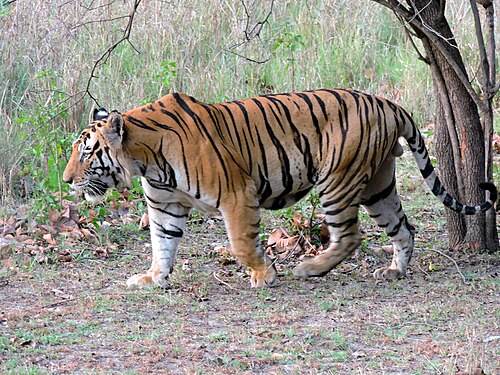

Output:  The animal in this image is a tiger. It's a large, majestic


In [7]:
from google.colab import files
from IPython.display import display
from PIL import Image

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")
display(image)

inputs = processor.process(
    images=[image],
    text="What is the animal in this image?"
)
inputs = {k: v.to(dtype=torch.bfloat16) if v.is_floating_point() else v for k, v in inputs.items()}
inputs = {k: v.to(model.device).unsqueeze(0) for k, v in inputs.items()}

with torch.no_grad():
    generated_ids = model.generate_from_batch(inputs, generation_config=generation_config, tokenizer=processor.tokenizer)

generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs['input_ids'], generated_ids)
]

output_text = processor.tokenizer.batch_decode(generated_ids_trimmed, skip_special_tokens=True)

print("Output:", output_text[0])

In [8]:
baseline_stats = {}
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        w = module.weight.data.float().to("cpu")
        flat = w.reshape(-1)
        scale = flat.abs().amax() / 1.0
        fractional = (flat / scale - (flat / scale).round()).abs()
        baseline_stats[name] = {
            "unique_vals": flat[:32].unique().numel(), # number of unique values in first 32 elements
            "mean_fractional": fractional.mean().item(),
        }

print(f"Baseline stats captured for {len(baseline_stats)} Linear layers ✓")

Baseline stats captured for 259 Linear layers ✓


In [9]:
import torch

def uniform_quantize(tensor, bits=8):
    """Per-tensor symmetric quantization"""
    max_val = 2 ** (bits - 1) - 1
    scale = tensor.abs().amax() / max_val
    scale = scale.clamp(min=1e-8)

    quantized = (tensor / scale).round().clamp(-max_val, max_val)
    dequantized = quantized * scale

    return dequantized


# Apply INT2
count = 0
with torch.no_grad():
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            module.weight.data = uniform_quantize(module.weight.data, bits=2)
            count += 1

print(f"INT2 applied to {count} Linear layers")

INT2 applied to 259 Linear layers


In [10]:
results = []
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        flat = module.weight.data.float().reshape(-1).to("cpu")
        scale = flat.abs().amax() / 1.0
        fractional = (flat / scale - (flat / scale).round()).abs()
        unique_vals = flat[:32].unique().numel() # number of unique values in first 32 elements
        results.append((name, fractional.mean().item(), unique_vals))

print(f"Total Linear layers quantized: {len(results)}\n")

for idx in [0, len(results)//2, len(results)-1]:
    name, frac, uniq = results[idx]
    if baseline_stats:
        baseline_frac = baseline_stats[name]["mean_fractional"]
        baseline_uniq = baseline_stats[name]["unique_vals"]
        print(f"Layer: {name}")
        print(f"  Fractional (base → quant): {baseline_frac:.8f} → {frac:.8f}")
        print(f"  Unique vals (base → quant): {baseline_uniq} → {uniq}")
    else:
        print(f"Layer: {name}")
        print(f"  Fractional (quant): {frac:.8f}")
        print(f"  Unique vals (quant): {uniq}")

print(f"\nMax fractional across all layers: {max(f for _,f,_ in results):.8f}")
print(f"All layers ≤256 unique vals: {all(u <= 256 for _,_,u in results)}")

Total Linear layers quantized: 259

Layer: model.transformer.blocks.0.attn_out
  Fractional (base → quant): 0.03004721 → 0.00000000
  Unique vals (base → quant): 29 → 1
Layer: model.vision_backbone.image_vit.transformer.resblocks.2.attention.wo
  Fractional (base → quant): 0.03813179 → 0.00000000
  Unique vals (base → quant): 32 → 1
Layer: model.vision_backbone.image_projector.w3
  Fractional (base → quant): 0.14176612 → 0.00000000
  Unique vals (base → quant): 31 → 1

Max fractional across all layers: 0.00000000
All layers ≤256 unique vals: True


In [11]:
image = Image.open("Bengal-Tiger-wikipedia.jpg").convert("RGB")

inputs = processor.process(
    images=[image],
    text="What is the animal in this image?"
)
inputs = {k: v.to(dtype=torch.bfloat16) if v.is_floating_point() else v for k, v in inputs.items()}
inputs = {k: v.to(model.device).unsqueeze(0) for k, v in inputs.items()}

with torch.no_grad():
    generated_ids = model.generate_from_batch(inputs, generation_config=generation_config, tokenizer=processor.tokenizer)

generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
]

output_text = processor.tokenizer.batch_decode(generated_ids_trimmed, skip_special_tokens=True)

print("Output:", output_text[0])

Output: ���������������


In [12]:
from PIL import Image, ImageOps
import numpy as np

def process_batch(
    processor,
    texts,
    images_list
):
    """
    Process in batch.

    Args:
        processor: The original processor.
        texts: List of text inputs
        images_list: List of lists containing PIL images.

    Returns:
        Dict with padded input_ids, images, image_input_idx, image_masks.
    """
    batch_size = len(texts)
    tokens_list = []
    for text in texts:
        tokens = processor.tokenizer.encode(" " + text, add_special_tokens=False)
        tokens_list.append(tokens)
    images_arrays_list = []
    image_idxs_list = []
    for images in images_list:
        if images:
            image_arrays = []
            for image in images:
                if isinstance(image, Image.Image):
                    image = image.convert("RGB")
                    image = ImageOps.exif_transpose(image)
                    image_arrays.append(np.array(image))
                else:
                    assert len(image.shape) == 3 and image.shape[-1] == 3
                    image_arrays.append(image.astype(np.uint8))
            images_arrays_list.append(image_arrays)
            image_idx = [-1] * len(image_arrays)
            image_idxs_list.append(image_idx)
        else:
            images_arrays_list.append(None)
            image_idxs_list.append(None)
    images_kwargs = {
        "max_crops": 12,
        "overlap_margins": [4, 4],
        "base_image_input_size": [336, 336],
        "image_token_length_w": 12,
        "image_token_length_h": 12,
        "image_patch_size": 14,
        "image_padding_mask": True,
    }
    outputs_list = []
    for i in range(batch_size):
        tokens = tokens_list[i]
        images = images_arrays_list[i]
        image_idx = image_idxs_list[i]
        out = processor.image_processor.multimodal_preprocess(
            images=images,
            image_idx=image_idx,
            tokens=np.asarray(tokens).astype(np.int32),
            sequence_length=1536,
            image_patch_token_id=processor.special_token_ids["<im_patch>"],
            image_col_token_id=processor.special_token_ids["<im_col>"],
            image_start_token_id=processor.special_token_ids["<im_start>"],
            image_end_token_id=processor.special_token_ids["<im_end>"],
            **images_kwargs,
        )
        outputs_list.append(out)

    batch_outputs = {}
    for key in outputs_list[0].keys():
        tensors = [torch.from_numpy(out[key]) for out in outputs_list]
        batch_outputs[key] = torch.nn.utils.rnn.pad_sequence(
            tensors, batch_first=True, padding_value=-1
        )
    bos = processor.tokenizer.bos_token_id or processor.tokenizer.eos_token_id
    batch_outputs["input_ids"] = torch.nn.functional.pad(
        batch_outputs["input_ids"], (1, 0), value=bos
    )
    if "image_input_idx" in batch_outputs:
        image_input_idx = batch_outputs["image_input_idx"]
        batch_outputs["image_input_idx"] = torch.where(
            image_input_idx < 0, image_input_idx, image_input_idx + 1
        )
    return batch_outputs

    for k in keys:
        tensors = [inp[k] for inp in all_inputs]
        pad_val = PAD_VALUES.get(k, 0)
        batched[k] = pad_sequence(tensors, batch_first=True, padding_value=pad_val)

    return batched


# VQA

In [13]:
# from google.colab import drive
# drive.mount('/content/drive')

import json
import base64
from PIL import Image
import io
from tqdm import tqdm

DRIVE_FILE = "/content/drive/MyDrive/Microscaling Benchmark/Data/vqav2_5k.jsonl"

samples = []
with open(DRIVE_FILE, "r") as f:
    for line in tqdm(f, total=5000):
        entry = json.loads(line)
        img_bytes = base64.b64decode(entry["image_b64"])
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        samples.append({
            "question_id": entry["question_id"],
            "question": entry["question"],
            "image": img,
            "answers": entry["answers"],
        })

print(f"Loaded {len(samples)} samples ✓")

100%|██████████| 5000/5000 [00:13<00:00, 365.88it/s]

Loaded 5000 samples ✓


In [14]:
import time

batch = samples[:4]

texts = []
images_list = []

for s in batch:
    img = s["image"]
    q = s["question"] + " Answer the question using a single word or phrase."
    texts.append(q)
    images_list.append([img])

inputs = process_batch(processor, texts, images_list)
inputs = {k: v.to(dtype=torch.bfloat16) if v.is_floating_point() else v for k, v in inputs.items()}
inputs = {k: v.to(model.device) for k, v in inputs.items()}


start = time.time()
with torch.no_grad():
    print("Input shape:", inputs["input_ids"].shape)
    print("VRAM used (GB):", torch.cuda.memory_allocated() / 1e9)
    generated_ids = model.generate_from_batch(
        inputs,
        generation_config=generation_config,
        tokenizer=processor.tokenizer
    )
elapsed = time.time() - start

input_len = inputs["input_ids"].shape[1]
preds = processor.tokenizer.batch_decode(
    generated_ids[:, input_len:].cpu(),
    skip_special_tokens=True
)

del generated_ids
torch.cuda.empty_cache()

sps = 4 / elapsed
print(f"4 samples in {elapsed:.1f}s — {sps:.2f} samples/sec — ETA for 5k: {5000/sps/60:.1f} mins\n")

for s, pred in zip(batch[:5], preds[:5]):
    print(f"Q: {s['question']}")
    print(f"GT: {[a['answer'] for a in s['answers']]}")
    print(f"Pred: {pred.strip().lower()}")
    print()

Input shape: torch.Size([4, 760])
VRAM used (GB): 16.13566976
4 samples in 3.6s — 1.11 samples/sec — ETA for 5k: 75.4 mins

Q: Where is he looking?
GT: ['down', 'down', 'at table', 'skateboard', 'down', 'table', 'down', 'down', 'down', 'down']
Pred: ���������������

Q: What are the people in the background doing?
GT: ['spectating', 'watching', 'watching', 'watching', 'watching', 'watching', 'watching', 'watching', 'watching', 'watching']
Pred: ���������������

Q: What is he on top of?
GT: ['table', 'table', 'table', 'picnic table', 'picnic table', 'picnic table', 'picnic table', 'picnic table', 'skateboard', 'picnic table']
Pred: ���������������

Q: What website copyrighted the picture?
GT: ['foodiebakercom', 'foodiebakercom', 'foodiebaker', 'foodiebakercom', 'foodiebakercom', 'http://foodiebakercom', 'foodiebakercom', 'foodiebakercom', 'foodiebakercom', 'foodiebaker']
Pred: ���������������



In [15]:
import json
import torch
import time

OUTPUT_FILE = "/content/drive/MyDrive/Microscaling Benchmark/Results/Molmo-7B-D/vqav2_int2_results.jsonl"
BATCH_SIZE = 4

with open(OUTPUT_FILE, "w") as f:
    pass
print("First run")

count = 0
start = time.time()

with open(OUTPUT_FILE, "a") as f_out:
    for i in range(0, len(samples), BATCH_SIZE):
        batch = samples[i:i+BATCH_SIZE]
        texts = []
        images_list = []

        for s in batch:
            img = s["image"]
            q = s["question"] + " Answer the question using a single word or phrase."
            texts.append(q)
            images_list.append([img])

        inputs = process_batch(processor, texts, images_list)
        inputs = {k: v.to(dtype=torch.bfloat16) if v.is_floating_point() else v for k, v in inputs.items()}
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            generated_ids = model.generate_from_batch(
                inputs,
                generation_config=generation_config,
                tokenizer=processor.tokenizer
            )

        input_len = inputs["input_ids"].shape[1]
        preds = processor.tokenizer.batch_decode(
            generated_ids[:, input_len:].cpu(),
            skip_special_tokens=True
        )

        del generated_ids
        torch.cuda.empty_cache()

        for s, pred in zip(batch, preds):
            result = {
                "question_id": s["question_id"],
                "question": s["question"],
                "prediction": pred.strip().lower(),
                "gt_answers": s["answers"],
            }
            f_out.write(json.dumps(result) + "\n")
        f_out.flush()

        count += len(batch)
        elapsed = time.time() - start
        if (count // 1000) > ((count - len(batch)) // 1000):
            sps = count / elapsed
            print(f"{count}/5000 — {sps:.2f} samples/sec — ETA: {(5000-count)/sps/60:.1f} mins")

print(f"\nDone — {count} samples written to {OUTPUT_FILE}")

First run
1000/5000 — 1.03 samples/sec — ETA: 64.7 mins
2000/5000 — 1.05 samples/sec — ETA: 47.4 mins
3000/5000 — 1.06 samples/sec — ETA: 31.5 mins
4000/5000 — 1.05 samples/sec — ETA: 15.8 mins
5000/5000 — 1.06 samples/sec — ETA: 0.0 mins

Done — 5000 samples written to /content/drive/MyDrive/Microscaling Benchmark/Results/Molmo-7B-D/vqav2_int2_results.jsonl


In [16]:
import json
import re

def normalize(answer):
    # Lowercase
    answer = answer.lower()
    # Remove articles
    answer = re.sub(r'\b(a|an|the)\b', ' ', answer)
    # Handle comma between digits (100,978 → 100978)
    answer = re.sub(r'(\d),(\d)', r'\1\2', answer)
    # Replace punctuation except apostrophe and colon with space
    answer = re.sub(r"[^\w\s':]", ' ', answer)
    # Normalize whitespace
    answer = ' '.join(answer.split())
    return answer.strip()

total_score = 0.0
total = 0

with open(OUTPUT_FILE, "r") as f:
    for line in f:
        entry = json.loads(line)
        pred = normalize(entry["prediction"])
        gt_answers = [normalize(a["answer"]) for a in entry["gt_answers"]]

        # Count how many GT answers match prediction
        match_count = sum(1 for gt in gt_answers if gt == pred)

        # Official VQA score: min(match_count / 3, 1)
        score = min(match_count / 3, 1.0)
        total_score += score
        total += 1

accuracy = total_score / total * 100
print(f"Samples evaluated: {total}")
print(f"VQA Accuracy: {accuracy:.2f}%")

Samples evaluated: 5000
VQA Accuracy: 0.07%


In [17]:
correct_examples = []
wrong_examples = []

all_entries = []
with open(OUTPUT_FILE, "r") as f:
    for line in f:
        all_entries.append(json.loads(line))

for entry in reversed(all_entries):
    pred = normalize(entry["prediction"])
    gt_answers = [normalize(a["answer"]) for a in entry["gt_answers"]]
    match_count = sum(1 for gt in gt_answers if gt == pred)
    score = min(match_count / 3, 1.0)

    if score == 1.0 and len(correct_examples) < 3:
        correct_examples.append((entry, pred, gt_answers, score))
    elif score == 0.0 and len(wrong_examples) < 3:
        wrong_examples.append((entry, pred, gt_answers, score))

    if len(correct_examples) == 3 and len(wrong_examples) == 3:
        break

print("=== CORRECT ===")
for entry, pred, gt_answers, score in correct_examples:
    print(f"Q: {entry['question']}")
    print(f"Pred: {pred}")
    print(f"GT: {list(set(gt_answers))}")
    print()

print("=== WRONG ===")
for entry, pred, gt_answers, score in wrong_examples:
    print(f"Q: {entry['question']}")
    print(f"Pred: {pred}")
    print(f"GT: {list(set(gt_answers))}")
    print()

=== CORRECT ===
Q: What letter is on the tail?
Pred: 
GT: ['']

=== WRONG ===
Q: What is the weather like?
Pred: 
GT: ['sunny', 'tranquil', 'clear']

Q: Are their leaves on the tree?
Pred: 
GT: ['yes']

Q: How many yellow stripes are painted on the street?
Pred: 
GT: ['multiple', '9', '20', '50', '7', 'at least 10', 'more than 10', '12', '1']



# TextVQA

In [18]:
import json
import base64
from PIL import Image
import io
from tqdm import tqdm

DRIVE_FILE = "/content/drive/MyDrive/Microscaling Benchmark/Data/textvqa_5k.jsonl"

textvqa_samples = []
with open(DRIVE_FILE, "r") as f:
    for line in tqdm(f, total=5000):
        entry = json.loads(line)
        img_bytes = base64.b64decode(entry["image_b64"])
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB").resize((448, 448))
        textvqa_samples.append({
            "question_id": entry["question_id"],
            "question": entry["question"],
            "image": img,
            "answers": entry["answers"],
        })

print(f"Loaded {len(textvqa_samples)} TextVQA samples ✓")

100%|██████████| 5000/5000 [01:17<00:00, 64.35it/s]

Loaded 5000 TextVQA samples ✓


In [ ]:
import time

batch = textvqa_samples[:4]

texts = []
images_list = []

for s in batch:
    img = s["image"]
    q = s["question"] + " Answer the question using a single word or phrase."
    texts.append(q)
    images_list.append([img])

inputs = process_batch(processor, texts, images_list)
inputs = {k: v.to(dtype=torch.bfloat16) if v.is_floating_point() else v for k, v in inputs.items()}
inputs = {k: v.to(model.device) for k, v in inputs.items()}

start = time.time()
with torch.no_grad():
    print("Input shape:", inputs["input_ids"].shape)
    generated_ids = model.generate_from_batch(
        inputs,
        generation_config=generation_config,
        tokenizer=processor.tokenizer
    )
elapsed = time.time() - start

input_len = inputs["input_ids"].shape[1]
preds = processor.tokenizer.batch_decode(
    generated_ids[:, input_len:].cpu(),
    skip_special_tokens=True
)

del generated_ids
torch.cuda.empty_cache()

sps = 4 / elapsed
print(f"4 samples in {elapsed:.1f}s — {sps:.2f} samples/sec — ETA for 5k: {5000/sps/60:.1f} mins\n")

for s, pred in zip(batch[:5], preds[:5]):
    print(f"Q: {s['question']}")
    print(f"GT: {s['answers']}")
    print(f"Pred: {pred.strip().lower()}")
    print()

In [20]:
import json
import torch
import time

OUTPUT_FILE = "/content/drive/MyDrive/Microscaling Benchmark/Results/Molmo-7B-D/textvqa_int2_results.jsonl"
BATCH_SIZE = 4

with open(OUTPUT_FILE, "w") as f:
    pass
print("First run")

count = 0
start = time.time()

with open(OUTPUT_FILE, "a") as f_out:
    for i in range(0, len(samples), BATCH_SIZE):
        batch = textvqa_samples[i:i+BATCH_SIZE]
        texts = []
        images_list = []

        for s in batch:
            img = s["image"]
            q = s["question"] + " Answer the question using a single word or phrase."
            texts.append(q)
            images_list.append([img])

        inputs = process_batch(processor, texts, images_list)
        inputs = {k: v.to(dtype=torch.bfloat16) if v.is_floating_point() else v for k, v in inputs.items()}
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            generated_ids = model.generate_from_batch(
                inputs,
                generation_config=generation_config,
                tokenizer=processor.tokenizer
            )

        input_len = inputs["input_ids"].shape[1]
        preds = processor.tokenizer.batch_decode(
            generated_ids[:, input_len:].cpu(),
            skip_special_tokens=True
        )

        del generated_ids
        torch.cuda.empty_cache()

        for s, pred in zip(batch, preds):
            result = {
                "question_id": s["question_id"],
                "question": s["question"],
                "prediction": pred.strip().lower(),
                "gt_answers": s["answers"],
            }
            f_out.write(json.dumps(result) + "\n")
        f_out.flush()

        count += len(batch)
        elapsed = time.time() - start
        if (count // 1000) > ((count - len(batch)) // 1000):
            sps = count / elapsed
            print(f"{count}/5000 — {sps:.2f} samples/sec — ETA: {(5000-count)/sps/60:.1f} mins")

print(f"\nDone — {count} samples written to {OUTPUT_FILE}")

First run
1000/5000 — 1.31 samples/sec — ETA: 50.7 mins
2000/5000 — 1.31 samples/sec — ETA: 38.1 mins
3000/5000 — 1.31 samples/sec — ETA: 25.4 mins
4000/5000 — 1.31 samples/sec — ETA: 12.7 mins
5000/5000 — 1.31 samples/sec — ETA: 0.0 mins

Done — 5000 samples written to /content/drive/MyDrive/Microscaling Benchmark/Results/Molmo-7B-D/textvqa_int2_results.jsonl


In [21]:
import json
import re

def normalize(answer):
    answer = answer.lower()
    answer = re.sub(r'\b(a|an|the)\b', ' ', answer)
    answer = re.sub(r'(\d),(\d)', r'\1\2', answer)
    answer = re.sub(r"[^\w\s':]", ' ', answer)
    answer = ' '.join(answer.split())
    return answer.strip()

total_score = 0.0
total = 0

with open(OUTPUT_FILE, "r") as f:
    for line in f:
        entry = json.loads(line)
        pred = normalize(entry["prediction"])
        gt_answers = [normalize(a) for a in entry["gt_answers"]]

        match_count = sum(1 for gt in gt_answers if gt == pred)
        score = min(match_count / 3, 1.0)
        total_score += score
        total += 1

accuracy = total_score / total * 100
print(f"Samples evaluated: {total}")
print(f"TextVQA Accuracy: {accuracy:.2f}%")

Samples evaluated: 5000
TextVQA Accuracy: 0.41%


In [22]:
correct_examples = []
wrong_examples = []

all_entries = []
with open(OUTPUT_FILE, "r") as f:
    for line in f:
        all_entries.append(json.loads(line))

for entry in reversed(all_entries):
    pred = normalize(entry["prediction"])
    gt_answers = [normalize(a) for a in entry["gt_answers"]]
    match_count = sum(1 for gt in gt_answers if gt == pred)
    score = min(match_count / 3, 1.0)

    if score == 1.0 and len(correct_examples) < 3:
        correct_examples.append((entry, pred, gt_answers))
    elif score == 0.0 and len(wrong_examples) < 3:
        wrong_examples.append((entry, pred, gt_answers))

    if len(correct_examples) == 3 and len(wrong_examples) == 3:
        break

print("=== CORRECT ===")
for entry, pred, gt_answers in correct_examples:
    print(f"Q: {entry['question']}")
    print(f"Pred: {pred}")
    print(f"GT: {list(set(gt_answers))}")
    print()

print("=== WRONG ===")
for entry, pred, gt_answers in wrong_examples:
    print(f"Q: {entry['question']}")
    print(f"Pred: {pred}")
    print(f"GT: {list(set(gt_answers))}")
    print()

=== CORRECT ===
Q: what is the first word on the page?
Pred: 
GT: ['', 'first word is couple']

Q: what is the word below in?
Pred: 
GT: ['']

Q: what letter does their shirt brand start with?
Pred: 
GT: ['', 'm']

=== WRONG ===
Q: when is this being aired?
Pred: 
GT: ['11:38 et', 'live', 'no text in image', 'live 11:39 eastern time', 'unanswerable']

Q: how many points does ga state have?
Pred: 
GT: ['58']

Q: what is the highest number on the players shorts?
Pred: 
GT: ['14', '8']

